# 02 — Gaussian Distributions: Properties & Geometry

> **Module:** `00-foundations/probabilities-estimation`  
> **Prerequisites:** `01_bayes_intro.ipynb`  
> **Time:** ~2h30  

---

## Why this notebook

In the previous notebook we saw that Bayesian estimation requires tracking probability distributions over states. In theory, these distributions can be anything — multimodal, skewed, discontinuous.

In practice, the Kalman filter and EKF make one critical assumption: **all distributions are Gaussian**.

This is not just a convenience. The Gaussian family has three properties that make it uniquely suited for recursive estimation:

1. **Closed under linear transformation** — if $\mathbf{x}$ is Gaussian and $\mathbf{y} = A\mathbf{x} + b$, then $\mathbf{y}$ is Gaussian
2. **Closed under multiplication** — the product of two Gaussians is (proportional to) a Gaussian
3. **Fully described by two parameters** — mean $\mu$ and covariance $\Sigma$: no need to track the full distribution

These three properties are why the Kalman filter can run in $O(n^3)$ per step instead of requiring a full numerical distribution.

---

## Learning objectives

By the end of this notebook you will be able to:

1. Define the univariate and multivariate Gaussian distributions
2. Interpret the covariance matrix geometrically (shape, orientation, scale of uncertainty)
3. Apply the linear transformation property
4. Compute marginal and conditional Gaussians
5. Explain why Gaussians are the natural choice for state estimation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy.stats import norm, multivariate_normal
from scipy.linalg import cholesky

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)

---
## Part 1 — The univariate Gaussian

### Definition

A random variable $X \sim \mathcal{N}(\mu, \sigma^2)$ has probability density:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Parameters:**
- $\mu$ — mean (location)
- $\sigma^2$ — variance (spread); $\sigma$ — standard deviation

### The 1-2-3 sigma rule

| Interval | Probability |
|----------|------------|
| $[\mu - \sigma,\ \mu + \sigma]$ | 68.3% |
| $[\mu - 2\sigma,\ \mu + 2\sigma]$ | 95.4% |
| $[\mu - 3\sigma,\ \mu + 3\sigma]$ | 99.7% |

In navigation: when we say our GPS estimate has $\sigma = 3$ m, we mean we are 99.7% confident the true position is within 9 m of the estimate.

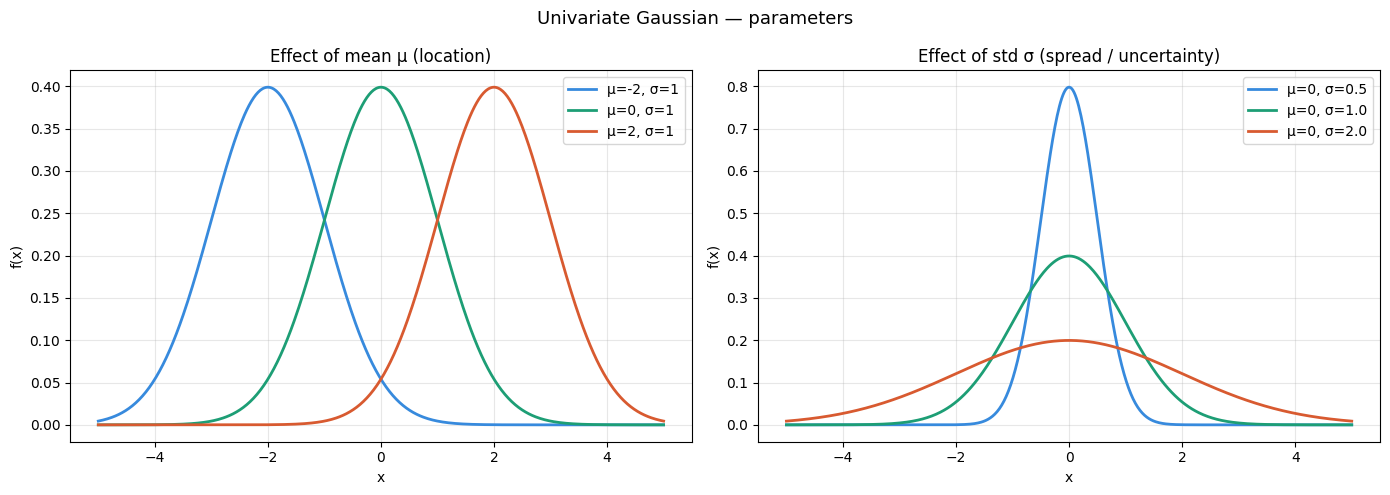

In [4]:
x = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: effect of varying mu ---
ax = axes[0]
for mu, color in [(-2, '#378ADD'), (0, '#1D9E75'), (2, '#D85A30')]:
    ax.plot(x, norm.pdf(x, mu, 1), color=color, linewidth=2, label=f'μ={mu}, σ=1')
ax.set_title('Effect of mean μ (location)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()

# --- Right: effect of varying sigma ---
ax = axes[1]
for sigma, color in [(0.5, '#378ADD'), (1.0, '#1D9E75'), (2.0, '#D85A30')]:
    ax.plot(x, norm.pdf(x, 0, sigma), color=color, linewidth=2, label=f'μ=0, σ={sigma}')
ax.set_title('Effect of std σ (spread / uncertainty)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()

plt.suptitle('Univariate Gaussian — parameters', fontsize=13)
plt.tight_layout()
plt.show()

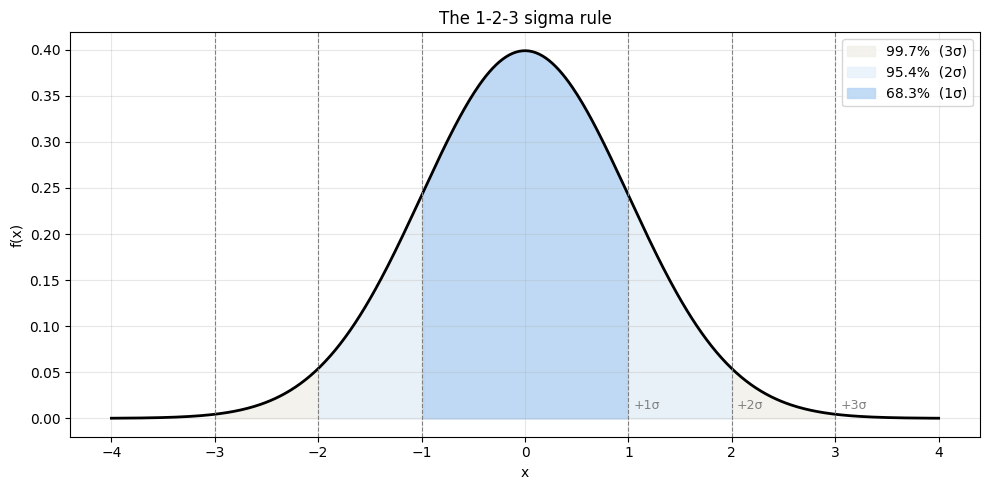

1σ interval: 68.3%
2σ interval: 95.4%
3σ interval: 99.7%


In [6]:
# Visualise the 1-2-3 sigma rule
mu, sigma = 0.0, 1.0
x = np.linspace(-4, 4, 500)
pdf = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, pdf, 'k-', linewidth=2)

fills = [
    (1, '#B5D4F4', '68.3%  (1σ)'),
    (2, '#E6F1FB', '95.4%  (2σ)'),
    (3, '#F1EFE8', '99.7%  (3σ)'),
]
for n, color, label in reversed(fills):
    mask = np.abs(x - mu) <= n * sigma
    ax.fill_between(x, pdf, where=mask, alpha=0.8, color=color, label=label)

for n in [1, 2, 3]:
    ax.axvline(mu + n*sigma, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(mu - n*sigma, color='gray', linestyle='--', linewidth=0.8)
    ax.text(mu + n*sigma + 0.05, 0.01, f'+{n}σ', fontsize=9, color='gray')

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('The 1-2-3 sigma rule')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Verify numerically
for n in [1, 2, 3]:
    p = norm.cdf(mu + n*sigma) - norm.cdf(mu - n*sigma)
    print(f'{n}σ interval: {p*100:.1f}%')

---
## Part 2 — The multivariate Gaussian

### Definition

For a vector $\mathbf{x} \in \mathbb{R}^n$:

$$\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \mathbf{\Sigma})$$

$$f(\mathbf{x}) = \frac{1}{(2\pi)^{n/2}|\mathbf{\Sigma}|^{1/2}} \exp\!\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})\right)$$

**Parameters:**
- $\boldsymbol{\mu} \in \mathbb{R}^n$ — mean vector
- $\mathbf{\Sigma} \in \mathbb{R}^{n \times n}$ — covariance matrix (symmetric, positive definite)

### The covariance matrix — structure

For a 2D state $\mathbf{x} = [x_1, x_2]^T$:

$$\mathbf{\Sigma} = \begin{bmatrix} \sigma_{11}^2 & \sigma_{12} \\ \sigma_{12} & \sigma_{22}^2 \end{bmatrix}$$

- $\sigma_{11}^2 = \text{Var}(x_1)$ — uncertainty in $x_1$
- $\sigma_{22}^2 = \text{Var}(x_2)$ — uncertainty in $x_2$  
- $\sigma_{12} = \text{Cov}(x_1, x_2)$ — correlation between $x_1$ and $x_2$

> **Navigation example:** if $x_1$ = position and $x_2$ = velocity, a non-zero $\sigma_{12}$ means that knowing the position error tells us something about the velocity error — they are correlated.

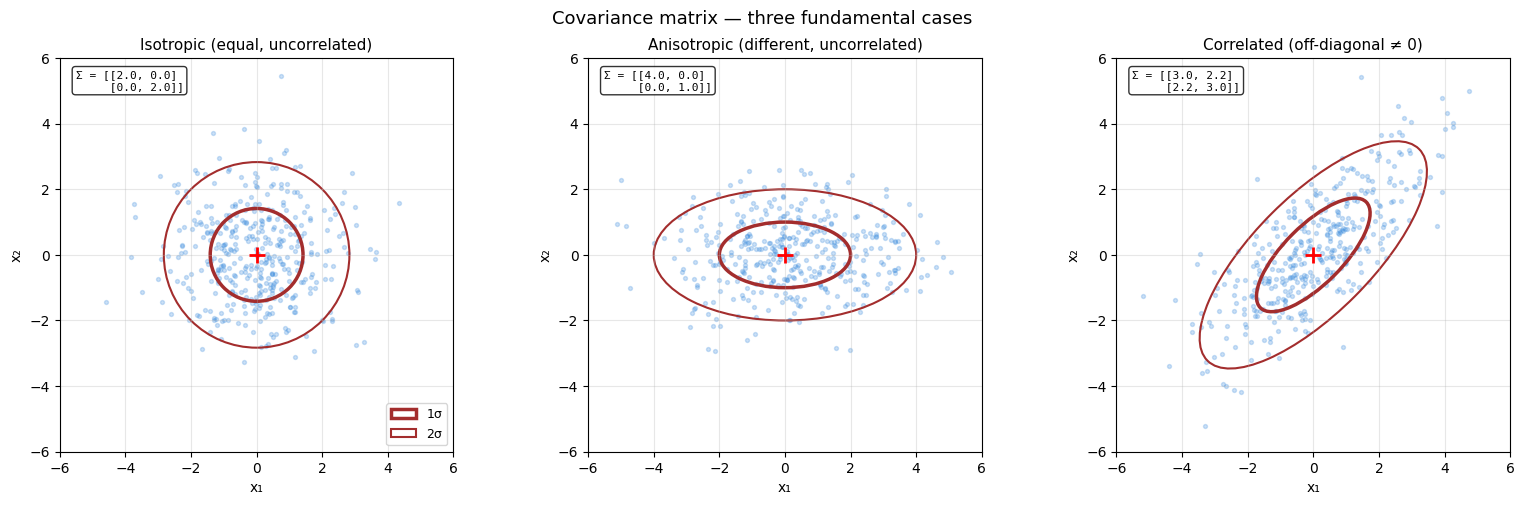

In [9]:
def plot_gaussian_2d(ax, mean, cov, n_samples=400, title=''):
    """Plot 2D Gaussian: samples + 1σ/2σ ellipses."""
    samples = np.random.multivariate_normal(mean, cov, n_samples)
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.25, s=8, color='#378ADD')

    for n_std, lw, label in [(1, 2.5, '1σ'), (2, 1.5, '2σ')]:
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        order = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
        width = 2 * n_std * np.sqrt(eigenvalues[0])
        height = 2 * n_std * np.sqrt(eigenvalues[1])
        ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                          fill=False, edgecolor='#A32D2D', linewidth=lw, label=label)
        ax.add_patch(ellipse)

    ax.plot(*mean, 'r+', markersize=12, markeredgewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')

    # Show covariance matrix
    ax.text(0.04, 0.97,
            f'Σ = [[{cov[0,0]:.1f}, {cov[0,1]:.1f}]\n     [{cov[1,0]:.1f}, {cov[1,1]:.1f}]]',
            transform=ax.transAxes, fontsize=8,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mean = [0.0, 0.0]

cases = [
    (np.array([[2.0, 0.0], [0.0, 2.0]]),  'Isotropic (equal, uncorrelated)'),
    (np.array([[4.0, 0.0], [0.0, 1.0]]),  'Anisotropic (different, uncorrelated)'),
    (np.array([[3.0, 2.2], [2.2, 3.0]]),  'Correlated (off-diagonal ≠ 0)'),
]

for ax, (cov, title) in zip(axes, cases):
    plot_gaussian_2d(ax, mean, cov, title=title)

axes[0].legend(fontsize=9, loc='lower right')
plt.suptitle('Covariance matrix — three fundamental cases', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 3 — Geometric interpretation: the covariance ellipse

The 1σ uncertainty ellipse is defined by all points $\mathbf{x}$ such that:

$$\underbrace{(\mathbf{x} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})}_{\text{Mahalanobis distance}^2} = 1$$

The **Mahalanobis distance** is the generalisation of "how many sigmas away" to multiple dimensions. It accounts for correlations — unlike Euclidean distance, it treats directions of high uncertainty as "closer".

### Eigendecomposition of Σ

$$\mathbf{\Sigma} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^T$$

- **Eigenvectors** $\mathbf{V}$ → principal axes of the ellipse (orientation)
- **Eigenvalues** $\boldsymbol{\lambda}$ → variance along each axis; semi-axes = $\sqrt{\lambda_i}$

This is exactly what the Kalman filter tracks: the eigenvectors tell you *where* the uncertainty is, the eigenvalues tell you *how much*.

Covariance matrix Σ:
[[3.  2.2]
 [2.2 3. ]]

Eigenvalues:  λ₁=5.200, λ₂=0.800
Semi-axes:    √λ₁=2.280, √λ₂=0.894

Eigenvectors (columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Orientation angle: 45.0°


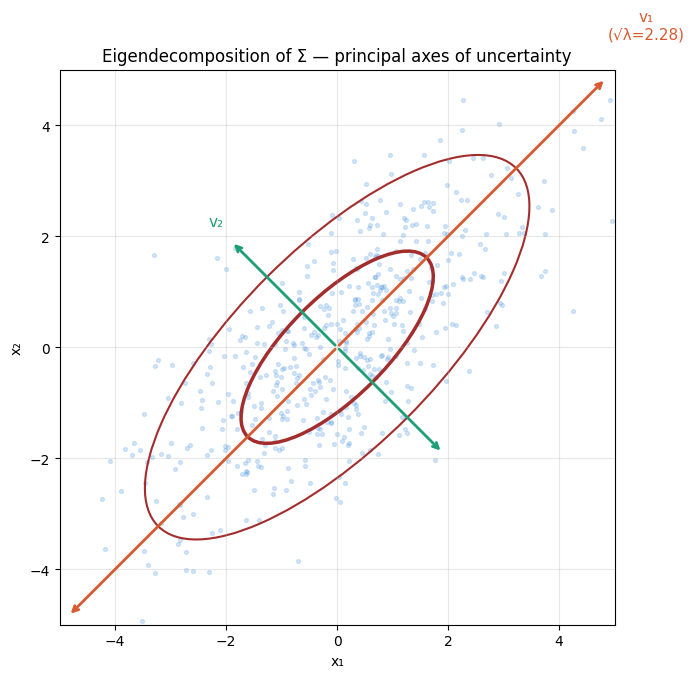

In [12]:
# Demonstrate eigendecomposition of a covariance matrix
Sigma = np.array([[3.0, 2.2],
                  [2.2, 3.0]])

eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
# Sort descending
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Covariance matrix Σ:")
print(Sigma)
print(f"\nEigenvalues:  λ₁={eigenvalues[0]:.3f}, λ₂={eigenvalues[1]:.3f}")
print(f"Semi-axes:    √λ₁={np.sqrt(eigenvalues[0]):.3f}, √λ₂={np.sqrt(eigenvalues[1]):.3f}")
print(f"\nEigenvectors (columns):")
print(eigenvectors)
print(f"\nOrientation angle: {np.degrees(np.arctan2(*eigenvectors[:,0][::-1])):.1f}°")

# Visualise
mean = np.array([0.0, 0.0])
samples = np.random.multivariate_normal(mean, Sigma, 500)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(samples[:, 0], samples[:, 1], alpha=0.2, s=8, color='#378ADD', label='Samples')

# Draw ellipse
angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
for n_std, lw in [(1, 2.5), (2, 1.5)]:
    e = Ellipse(xy=mean,
                width=2*n_std*np.sqrt(eigenvalues[0]),
                height=2*n_std*np.sqrt(eigenvalues[1]),
                angle=angle, fill=False, edgecolor='#A32D2D', linewidth=lw)
    ax.add_patch(e)

# Draw principal axes
scale = 3.0
colors = ['#D85A30', '#1D9E75']
for i in range(2):
    v = eigenvectors[:, i] * scale * np.sqrt(eigenvalues[i])
    ax.annotate('', xy=mean + v, xytext=mean,
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2))
    ax.annotate('', xy=mean - v, xytext=mean,
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2))
    ax.text(*(mean + v*1.15), f'v₂' if i else f'v₁\n(√λ={np.sqrt(eigenvalues[i]):.2f})',
            fontsize=11, color=colors[i], ha='center')

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.set_title('Eigendecomposition of Σ — principal axes of uncertainty', fontsize=12)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
plt.tight_layout()
plt.show()

---
## Part 4 — Linear transformation property

This is the property that makes the Kalman **prediction step** exact.

**Theorem:** If $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \mathbf{\Sigma})$ and $\mathbf{y} = \mathbf{A}\mathbf{x} + \mathbf{b}$, then:

$$\mathbf{y} \sim \mathcal{N}(\mathbf{A}\boldsymbol{\mu} + \mathbf{b},\ \mathbf{A}\mathbf{\Sigma}\mathbf{A}^T)$$

**In plain English:** propagating a Gaussian through a linear function just transforms the mean and covariance — the result is still Gaussian.

**In the Kalman filter:** the state transition $\mathbf{x}_k = \mathbf{A}\mathbf{x}_{k-1} + \mathbf{w}$ is linear, so:

$$\hat{\mathbf{x}}_k^- = \mathbf{A}\hat{\mathbf{x}}_{k-1}$$
$$\mathbf{P}_k^- = \mathbf{A}\mathbf{P}_{k-1}\mathbf{A}^T + \mathbf{Q}$$

These are **exactly** the Kalman prediction equations — they follow directly from this theorem.

In [15]:
# Demonstrate linear transformation of a Gaussian
# Physical meaning: a drone at position [x, y] moves with a rotation+scale transformation

mu_x = np.array([2.0, 1.0])
Sigma_x = np.array([[1.5, 0.5],
                    [0.5, 0.8]])

# Transformation matrix A: rotation by 45° + slight scaling
theta = np.radians(45)
A = 1.3 * np.array([[np.cos(theta), -np.sin(theta)],
                    [np.sin(theta),  np.cos(theta)]])
b = np.array([1.0, 0.5])

# Analytical result
mu_y = A @ mu_x + b
Sigma_y = A @ Sigma_x @ A.T

# Empirical verification (Monte Carlo)
N = 5000
samples_x = np.random.multivariate_normal(mu_x, Sigma_x, N)
samples_y = (A @ samples_x.T).T + b

print("Input distribution:")
print(f"  μ_x = {mu_x}")
print(f"  Σ_x = {Sigma_x}")
print(f"\nTransformation A:")
print(A)
print(f"\nAnalytical output:")
print(f"  μ_y = A·μ_x + b = {mu_y.round(3)}")
print(f"  Σ_y = A·Σ_x·Aᵀ =\n{Sigma_y.round(3)}")
print(f"\nEmpirical output (Monte Carlo, N={N}):")
print(f"  μ_y ≈ {samples_y.mean(axis=0).round(3)}")
print(f"  Σ_y ≈\n{np.cov(samples_y.T).round(3)}")

Input distribution:
  μ_x = [2. 1.]
  Σ_x = [[1.5 0.5]
 [0.5 0.8]]

Transformation A:
[[ 0.91923882 -0.91923882]
 [ 0.91923882  0.91923882]]

Analytical output:
  μ_y = A·μ_x + b = [1.919 3.258]
  Σ_y = A·Σ_x·Aᵀ =
[[1.099 0.592]
 [0.592 2.789]]

Empirical output (Monte Carlo, N=5000):
  μ_y ≈ [1.938 3.264]
  Σ_y ≈
[[1.082 0.596]
 [0.596 2.853]]


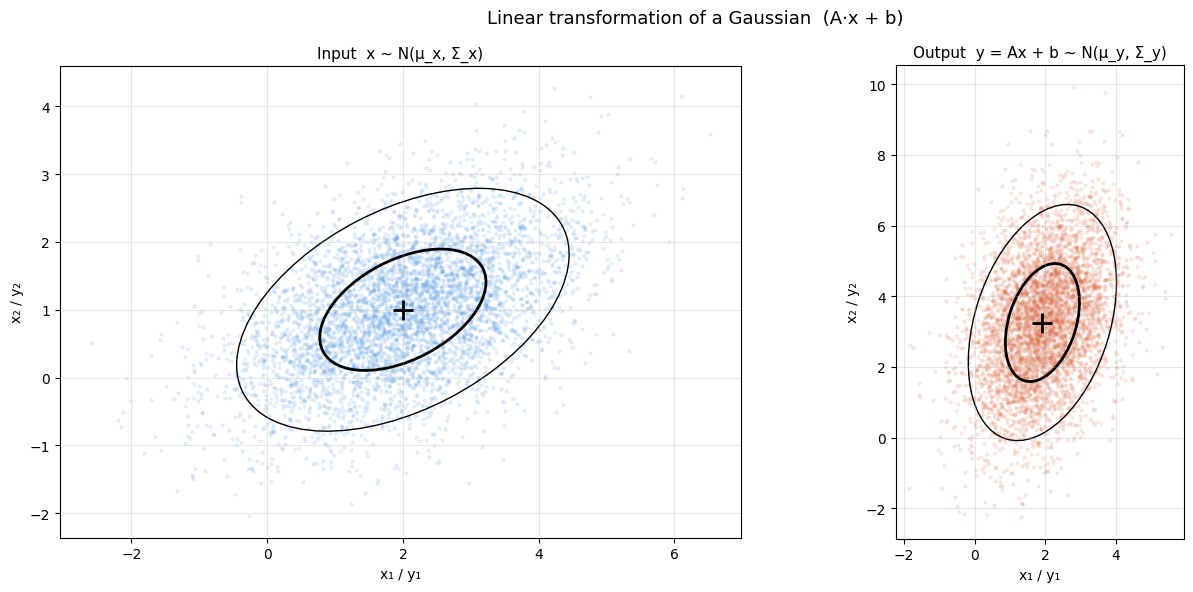

In [17]:
def cov_ellipse_params(cov):
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[idx], eigenvectors[:, idx]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    return np.sqrt(eigenvalues[0]), np.sqrt(eigenvalues[1]), angle


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (samples, mu, cov, label, color) in zip(axes, [
    (samples_x, mu_x, Sigma_x, 'Input  x ~ N(μ_x, Σ_x)', '#378ADD'),
    (samples_y, mu_y, Sigma_y, 'Output  y = Ax + b ~ N(μ_y, Σ_y)', '#D85A30'),
]):
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.1, s=4, color=color)
    ax.plot(*mu, '+', color='black', markersize=14, markeredgewidth=2)

    w, h, angle = cov_ellipse_params(cov)
    for n in [1, 2]:
        e = Ellipse(xy=mu, width=2*n*w, height=2*n*h, angle=angle,
                    fill=False, edgecolor='black', linewidth=2 if n == 1 else 1)
        ax.add_patch(e)

    ax.set_title(label, fontsize=11)
    ax.set_aspect('equal')
    ax.set_xlabel('x₁ / y₁')
    ax.set_ylabel('x₂ / y₂')

plt.suptitle('Linear transformation of a Gaussian  (A·x + b)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 5 — Marginal and conditional Gaussians

Two more properties essential for sensor fusion.

### Marginalisation

Given a joint distribution over $[\mathbf{x}_1, \mathbf{x}_2]$, the marginal over $\mathbf{x}_1$ alone is:

$$p(\mathbf{x}_1) = \int p(\mathbf{x}_1, \mathbf{x}_2)\, d\mathbf{x}_2 = \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_{11})$$

Just read off the relevant block of the joint mean and covariance.

### Conditioning

Given a measurement $\mathbf{x}_2 = \mathbf{z}$, the conditional distribution is:

$$p(\mathbf{x}_1 \mid \mathbf{x}_2 = \mathbf{z}) = \mathcal{N}(\boldsymbol{\mu}_{1|2},\ \boldsymbol{\Sigma}_{1|2})$$

$$\boldsymbol{\mu}_{1|2} = \boldsymbol{\mu}_1 + \boldsymbol{\Sigma}_{12}\boldsymbol{\Sigma}_{22}^{-1}(\mathbf{z} - \boldsymbol{\mu}_2)$$

$$\boldsymbol{\Sigma}_{1|2} = \boldsymbol{\Sigma}_{11} - \boldsymbol{\Sigma}_{12}\boldsymbol{\Sigma}_{22}^{-1}\boldsymbol{\Sigma}_{21}$$

> **Recognition:** $\boldsymbol{\Sigma}_{12}\boldsymbol{\Sigma}_{22}^{-1}$ is the **Kalman gain** $\mathbf{K}$. The conditioning formula *is* the Kalman update step. We will formalise this in Module 01.

In [20]:
# Concrete example: joint distribution over position (x1) and velocity (x2)
# Correlated because a faster-moving object was probably at a different position

mu_joint = np.array([10.0, 2.0])  # [position (m), velocity (m/s)]
Sigma_joint = np.array([[4.0, 1.8],   # position variance = 4 m²; cov(pos,vel) = 1.8
                        [1.8, 1.0]])  # velocity variance = 1 (m/s)²

# --- Marginals ---
mu1, var1 = mu_joint[0], Sigma_joint[0, 0]
mu2, var2 = mu_joint[1], Sigma_joint[1, 1]

print("Joint distribution:")
print(f"  μ = {mu_joint}, Σ =\n  {Sigma_joint}")
print(f"\nMarginal p(position):   N({mu1}, {var1}) → std = {np.sqrt(var1):.2f} m")
print(f"Marginal p(velocity):   N({mu2}, {var2}) → std = {np.sqrt(var2):.2f} m/s")

# --- Conditioning: we measure velocity = 3 m/s ---
z_vel = 3.0

K = Sigma_joint[0, 1] / Sigma_joint[1, 1]  # Kalman-gain-like term
mu_cond = mu1 + K * (z_vel - mu2)
var_cond = Sigma_joint[0, 0] - Sigma_joint[0, 1]**2 / Sigma_joint[1, 1]

print(f"\nAfter observing velocity = {z_vel} m/s:")
print(f"  Conditional p(position | velocity={z_vel}):")
print(f"  Mean shifted from {mu1} m → {mu_cond:.3f} m")
print(f"  Std reduced from  {np.sqrt(var1):.3f} m → {np.sqrt(var_cond):.3f} m")
print(f"\n  K (Kalman-like gain) = {K:.3f}")
print("  → Measuring velocity REDUCES uncertainty in position (because they are correlated)")

Joint distribution:
  μ = [10.  2.], Σ =
  [[4.  1.8]
 [1.8 1. ]]

Marginal p(position):   N(10.0, 4.0) → std = 2.00 m
Marginal p(velocity):   N(2.0, 1.0) → std = 1.00 m/s

After observing velocity = 3.0 m/s:
  Conditional p(position | velocity=3.0):
  Mean shifted from 10.0 m → 11.800 m
  Std reduced from  2.000 m → 0.872 m

  K (Kalman-like gain) = 1.800
  → Measuring velocity REDUCES uncertainty in position (because they are correlated)


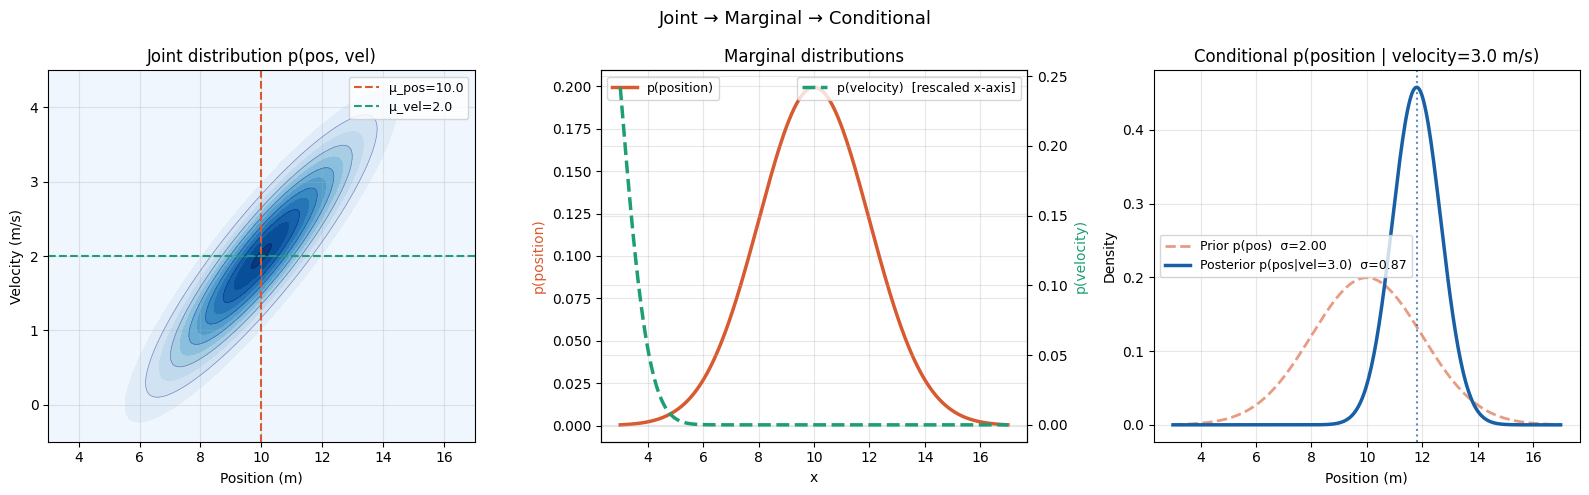

In [22]:
# Visualise joint, marginals, and conditional
x1 = np.linspace(3, 17, 300)
x2 = np.linspace(-0.5, 4.5, 300)
X1, X2 = np.meshgrid(x1, x2)
pos = np.dstack((X1, X2))

rv = multivariate_normal(mu_joint, Sigma_joint)
Z = rv.pdf(pos)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Joint
axes[0].contourf(X1, X2, Z, levels=15, cmap='Blues')
axes[0].contour(X1, X2, Z, levels=6, colors='navy', linewidths=0.5, alpha=0.4)
axes[0].axvline(mu1, color='#D85A30', linestyle='--', linewidth=1.5, label=f'μ_pos={mu1}')
axes[0].axhline(mu2, color='#1D9E75', linestyle='--', linewidth=1.5, label=f'μ_vel={mu2}')
axes[0].set_xlabel('Position (m)')
axes[0].set_ylabel('Velocity (m/s)')
axes[0].set_title('Joint distribution p(pos, vel)')
axes[0].legend(fontsize=9)

# Marginals
axes[1].plot(x1, norm.pdf(x1, mu1, np.sqrt(var1)), '#D85A30', linewidth=2.5, label='p(position)')
ax2_twin = axes[1].twinx()
ax2_twin.plot(x1, norm.pdf(x1, mu2, np.sqrt(var2)), '#1D9E75', linewidth=2.5,
              linestyle='--', label='p(velocity)  [rescaled x-axis]')
axes[1].set_xlabel('x')
axes[1].set_ylabel('p(position)', color='#D85A30')
ax2_twin.set_ylabel('p(velocity)', color='#1D9E75')
axes[1].set_title('Marginal distributions')
axes[1].legend(loc='upper left', fontsize=9)
ax2_twin.legend(loc='upper right', fontsize=9)

# Conditional
axes[2].plot(x1, norm.pdf(x1, mu1, np.sqrt(var1)), '#D85A30',
             linewidth=2, linestyle='--', alpha=0.6, label=f'Prior p(pos)  σ={np.sqrt(var1):.2f}')
axes[2].plot(x1, norm.pdf(x1, mu_cond, np.sqrt(var_cond)), '#185FA5',
             linewidth=2.5, label=f'Posterior p(pos|vel={z_vel})  σ={np.sqrt(var_cond):.2f}')
axes[2].axvline(mu_cond, color='#185FA5', linestyle=':', alpha=0.7)
axes[2].set_xlabel('Position (m)')
axes[2].set_ylabel('Density')
axes[2].set_title(f'Conditional p(position | velocity={z_vel} m/s)')
axes[2].legend(fontsize=9)

plt.suptitle('Joint → Marginal → Conditional', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 6 — Why not other distributions?

It is worth understanding what we give up by assuming Gaussians.


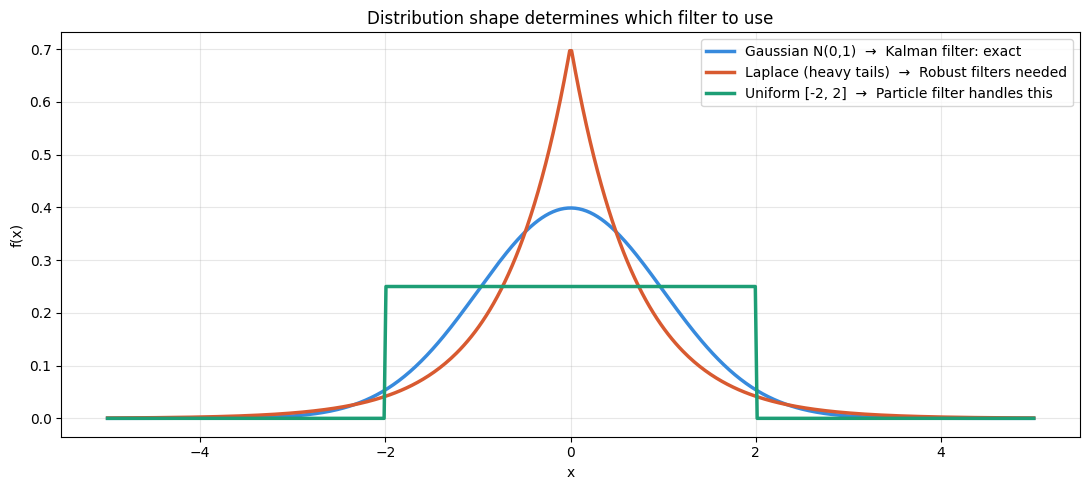

Summary of assumptions:
  Kalman Filter  → Gaussian noise, linear model   (exact)
  EKF / UKF      → Gaussian noise, nonlinear model (approximate)
  Particle Filter → Any distribution               (approximate, computationally heavy)


In [25]:
from scipy.stats import uniform, laplace, expon

x = np.linspace(-5, 5, 500)

distributions = [
    (norm(0, 1),             '#378ADD', 'Gaussian N(0,1)',         'Kalman filter: exact'),
    (laplace(0, 1/np.sqrt(2)),'#D85A30', 'Laplace (heavy tails)',   'Robust filters needed'),
    (uniform(-2, 4),         '#1D9E75', 'Uniform [-2, 2]',         'Particle filter handles this'),
]

fig, ax = plt.subplots(figsize=(11, 5))
for dist, color, label, note in distributions:
    y = dist.pdf(x)
    ax.plot(x, y, color=color, linewidth=2.5, label=f'{label}  →  {note}')

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Distribution shape determines which filter to use')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Summary of assumptions:")
print("  Kalman Filter  → Gaussian noise, linear model   (exact)")
print("  EKF / UKF      → Gaussian noise, nonlinear model (approximate)")
print("  Particle Filter → Any distribution               (approximate, computationally heavy)")

---
## Exercises

### Exercise 1 — Covariance matrix geometry

Given the covariance matrix:

$$\mathbf{\Sigma} = \begin{bmatrix} 9 & -4 \\ -4 & 4 \end{bmatrix}$$

**Q1:** Compute eigenvalues and eigenvectors analytically (or with numpy).  
**Q2:** What are the semi-axis lengths of the 1σ ellipse?  
**Q3:** What is the orientation angle?  
**Q4:** Plot 500 samples and overlay the 1σ and 2σ ellipses.  
**Q5:** What does the negative off-diagonal ($-4$) mean physically for a [position, velocity] state?

In [ ]:
# Exercise 1 — your solution
Sigma_ex = np.array([[9.0, -4.0],
                     [-4.0,  4.0]])

# TODO: eigendecomposition
# TODO: plot

### Exercise 2 — Linear transformation

A 2D drone position is distributed as $\mathbf{x} \sim \mathcal{N}([5, 3]^T, \mathbf{I}_2)$.

It moves for 1 second with velocity $[2, -1]^T$ m/s.

The new position is $\mathbf{y} = \mathbf{x} + \Delta t \cdot \mathbf{v}$ where $\Delta t = 1$.

**Q1:** Express this as $\mathbf{y} = \mathbf{A}\mathbf{x} + \mathbf{b}$.  
**Q2:** Compute $\boldsymbol{\mu}_y$ and $\mathbf{\Sigma}_y$ analytically.  
**Q3:** Did the uncertainty change? Why or why not?  
**Q4:** Now add process noise $\mathbf{Q} = 0.1\mathbf{I}_2$. Recompute $\mathbf{\Sigma}_y$. What changed?

In [ ]:
# Exercise 2 — your solution
mu_x_ex2 = np.array([5.0, 3.0])
Sigma_x_ex2 = np.eye(2)
v = np.array([2.0, -1.0])
dt = 1.0
Q = 0.1 * np.eye(2)

# TODO: compute A, b, mu_y, Sigma_y (without Q, then with Q)

### Exercise 3 — Conditional Gaussian (sensor fusion preview)

A drone's joint state over altitude $h$ (m) and vertical velocity $\dot{h}$ (m/s) is:

$$\boldsymbol{\mu} = [100,\ 2]^T, \quad \mathbf{\Sigma} = \begin{bmatrix} 16 & 6 \\ 6 & 4 \end{bmatrix}$$

A barometer measures $\dot{h} = 3.5$ m/s.

**Q1:** Compute the conditional mean and variance for altitude given $\dot{h} = 3.5$.  
**Q2:** By how many metres did the mean altitude estimate change?  
**Q3:** By what factor did the altitude uncertainty reduce?  
**Q4:** Identify the Kalman gain term in your calculation.

In [ ]:
# Exercise 3 — your solution
mu_joint_ex3 = np.array([100.0, 2.0])
Sigma_joint_ex3 = np.array([[16.0, 6.0],
                            [6.0,  4.0]])
z_vdot = 3.5

# TODO: compute conditional mean and variance
# Recall: K = Sigma_12 / Sigma_22
#         mu_cond  = mu_1 + K * (z - mu_2)
#         var_cond = Sigma_11 - K * Sigma_21

---
## Summary

| Property | Formula | Use in filtering |
|----------|---------|------------------|
| Definition | $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ | State representation |
| 1-2-3 sigma rule | 68 / 95 / 99.7% | Uncertainty interpretation |
| Eigendecomposition | $\boldsymbol{\Sigma} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^T$ | Ellipse orientation & size |
| Linear transform | $\mathbf{A}\boldsymbol{\mu} + \mathbf{b}$, $\mathbf{A}\boldsymbol{\Sigma}\mathbf{A}^T$ | **Kalman prediction step** |
| Conditioning | $\boldsymbol{\mu}_{1|2}$, $\boldsymbol{\Sigma}_{1|2}$ | **Kalman update step** |
| Gaussian assumption | Exact for KF, approx for EKF | Filter selection guide |

**Next notebook:** `03_bayesian_sequential_update.ipynb` — putting it all together: recursive Bayesian estimation with prediction + update cycles, building directly toward the Kalman filter.